# Single-encounter figures (Figs 7 and 8)

This notebook makes the single-encounter figures of the paper:

* Fig. 7: perpendicular against parallel encounters;
* Fig. 8: example outcomes of vertical encounters for a range of subhalo masses and scale radii.

The model is the one used throughout the paper:

* **Bar.** The analytic Chiba et al. (2021) bar with $A=0.02$, the bar used by the analytic model ($\epsilon\simeq 529\,{\rm km^2\,s^{-2}}$). `BAR = 'ferrers'` uses a Ferrers bar instead, whose $m=2$ term at co-rotation is about 30 times weaker.
* **Host frame.** With `HOST_FRAME = True`, the orbit is integrated in the host frame. The added acceleration is minus the mean subhalo acceleration of the host mass enclosed by the orbit (the differential force of Sec. 3.1).
* **Units of $\Delta I$.** $\Delta I = \Delta L_z/m$ is quoted in units of the full resonance width $2\Delta I_{\rm half}$, with $\Delta I_{\rm half}=2\sqrt{\epsilon/\alpha}$.
* **Measurement.** $\Delta I$ is read from $t_{\rm enc}+\delta t$, with $\delta t=4(b+r_s)/u$ as in `ejection_calibration.ipynb`, and averaged over one radial period (`MEAS = 'orbit_avg'`).
* **Ejection.** The slow angle $\psi=m(\varphi-\Omega_{\rm p}t)$, averaged over one radial period, spans more than $2\pi$ after the encounter. The average removes the epicyclic swing of $\varphi$; without it, a star thrown onto an eccentric orbit that still librates would be counted as ejected.


In [1]:
import os, tempfile
import shutil
if os.path.isdir("/Library/TeX/texbin"):                         # TeX Live on macOS
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
from scipy.optimize import brentq
import agama

rcParams.update({
    "text.usetex": shutil.which("latex") is not None,   # falls back to mathtext if no LaTeX is installed
    "font.family": "serif", "font.serif": ["Computer Modern"],
    "axes.labelsize": 14, "font.size": 18, "legend.fontsize": 12,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}"
})
agama.setUnits(mass=1, length=1, velocity=1)   # time unit = kpc/(km/s) = 0.978 Gyr
G = 4.300917e-6

## Settings

In [2]:
BAR        = 'hamilton'   # 'hamilton' (A = 0.02, as in the analytic model) or 'ferrers' (Ferrers bar, weaker m = 2 term)
HOST_FRAME = True         # differential force: integrate in the host frame
T_ENC      = 4.37         # encounter time [kpc/(km/s)]
W_SUB      = 200.         # subhalo speed |w| [km/s]
DT_MEAS_FAC, DT_MEAS_RANGE = 4, (0.01, 0.05)   # Delta I is measured from t_enc + 4 (b + r_s)/u, limited to 0.01-0.05 (~10-50 Myr), as in ejection_calibration
MEAS       = 'orbit_avg'      # 'point': Delta L_z / m at that time (Delta I_sim of ejection_calibration)
                          # 'orbit_avg': averaged over one radial period starting there (guiding centre; less noisy
                          #              for violent encounters that leave the star on an eccentric orbit)
DI_SYM     = r'\langle\Delta I\rangle' if MEAS == 'orbit_avg' else r'\Delta I'   # label for the measured change in slow action in Figs 7 and 8

# Fig. 7: two geometries x two concentrations at fixed mass
M_FIG7     = 1e10
FS_FIG7    = dict(vertical=[0.25, 0.01], parallel=[0.25, 0.05])   # r_s / r_s^CDM: [trapped (solid), ejected (dashed)]
BDIR_FIG7  = dict(vertical='radial', parallel='azimuth')   # direction of b for each geometry (see the encounter machinery)

# Fig. 8: grid of examples (vertical, b along azimuth). r_s / r_s^CDM is chosen per mass so that the rows have similar
# |Delta I|: ~0 and ~0.15 (trapped), ~2.4 and ~3.0 (ejected). For |Delta I| ~ 0.4-2 a vertical encounter leaves the
# star on an eccentric orbit that still librates, so an ejection with |Delta I| > 1 needs |Delta I| >~ 2.
FS_FIG8    = {1e9: [1.0, 0.1, 0.003, 0.002], 1e10: [1.0, 0.15, 0.01, 0.007]}
M_FIG8     = list(FS_FIG8)

SAVE_FIGS  = True
v0, r_core, omega_p, m_res = 230., 0.1, 35., 2
scale_radius_plu = lambda M: 1.62*(M/1e8)**0.5

## Host potential, bar and resonance properties

The potentials match `ejection_calibration.ipynb`: $\epsilon$ is the cosine amplitude of the $m=2$ term at co-rotation, $\alpha=m\,|d\omega_{\rm res}/dL_z|$, and $\Delta I_{\rm half}=2\sqrt{\epsilon/\alpha}$. The star starts at co-rotation with $v_\varphi$ offset by $0.02\,v_0$ from the circular speed, and is integrated for 8 time units with $2^{13}$ samples.

In [3]:
halo  = agama.Potential(type='Logarithmic', v0=v0, scaleRadius=r_core)
R_CR0 = v0/omega_p

def hamilton_bar_static(xyz, A_bar=0.02, b_bar=0.28, z_b=1.0):
    '''Chiba, Friske & Schoenrich (2021) bar at t = 0 (major axis along x).'''
    R = np.hypot(xyz[:,0], xyz[:,1]); phi = np.arctan2(xyz[:,1], xyz[:,0]); z = xyz[:,2]; s = R/R_CR0
    return -A_bar*v0**2/2*np.cos(2*phi)*s**2*((b_bar+1)/(b_bar+s))**5*np.exp(-z**2/(2*z_b**2))

if BAR == 'hamilton':
    bar_static = agama.Potential(type='CylSpline', potential=agama.Potential(hamilton_bar_static, symmetry='bisymmetric'),
                                 mmax=4, symmetry='bisymmetric', gridSizeR=50, gridSizez=30,
                                 Rmin=0.05, Rmax=60, zmin=0.05, zmax=20)
elif BAR == 'ferrers':
    bar_static = agama.Potential(type='Ferrers', mass=10**9.15, scaleRadius=3.5, axisRatioY=1.4/3.5, axisRatioZ=1.0/3.5)
static = agama.Potential(halo, bar_static)

def vc_axi(R, pot):
    ph = np.linspace(0, 2*np.pi, 128, endpoint=False)
    F  = pot.force(np.column_stack([R*np.cos(ph), R*np.sin(ph), 0*ph]))
    return np.sqrt(-R*np.sum(F[:, :2]*np.column_stack([np.cos(ph), np.sin(ph)]), 1).mean())

R_res = brentq(lambda R: vc_axi(R, static)/R - omega_p, 1, 20)
ph    = np.linspace(0, 2*np.pi, 256, endpoint=False)
Phi   = static.potential(np.column_stack([R_res*np.cos(ph), R_res*np.sin(ph), 0*ph]))
eps   = 2*abs(np.mean((Phi - Phi.mean())*np.exp(-2j*ph)))
dR    = 1e-3*R_res
w_res = lambda R: m_res*(vc_axi(R, static)/R - omega_p)
L_of  = lambda R: R*vc_axi(R, static)
alpha = m_res*abs((w_res(R_res+dR) - w_res(R_res-dR))/(L_of(R_res+dR) - L_of(R_res-dR)))
dI_half = 2*np.sqrt(eps/alpha); W = 2*dI_half
LZ_CR   = R_CR0*v0
print(f"BAR = {BAR}: R_res = {R_res:.3f} kpc, eps = {eps:.3g} (km/s)^2, alpha = {alpha:.4g} kpc^-2")
print(f"Delta I_half = {dI_half:.3g} kpc km/s  ->  Delta L_z,half / L_z^CR = {m_res*dI_half/LZ_CR:.3f}")

# star in co-rotation resonance: initial condition and time sampling
T_END = 8.0
times = np.linspace(0, T_END, int(T_END)*2**10)
DT    = times[1] - times[0]
bar   = agama.Potential(potential=bar_static, rotation=np.column_stack([times, omega_p*times]))
pot   = agama.Potential(halo, bar)
ic    = np.array([0, R_res, 0, -(vc_axi(R_res, static) + 0.02*v0), 0, 0])
_, posvels = agama.orbit(potential=pot, ic=ic, time=T_END, trajsize=len(times), dtype=float)

BAR = hamilton: R_res = 6.571 kpc, eps = 529 (km/s)^2, alpha = 0.09261 kpc^-2
Delta I_half = 151 kpc km/s  ->  Delta L_z,half / L_z^CR = 0.200


## Encounter machinery

The encounter conventions are:

* vertical encounter: $\mathbf w=(0,0,|\mathbf w|)$;
* parallel encounter: $\mathbf w=|\mathbf w|\,\hat{\mathbf v}_\star$;
* $\mathbf b$ is the chosen direction ($\hat{\mathbf e}_R$, $\hat{\mathbf e}_\varphi$ or $\hat{\mathbf e}_z$) projected perpendicular to $\mathbf u=\mathbf w-\mathbf v_\star$, with $|\mathbf b| = r_s$;
* the subhalo moves on a straight line in the inertial frame.

For the parallel encounter, $\mathbf u$ is almost exactly along $\hat{\mathbf e}_\varphi$, so `b_dir='azimuth'` collapses to the small residual of $\hat{\mathbf e}_\varphi$ perpendicular to $\mathbf u$. That residual points radially inwards.

With `HOST_FRAME = True`, a uniform acceleration $-\langle\mathbf a_{\rm sh}(\mathbf y,t)\rangle_y$ is added, where $\mathbf y$ samples the host mass enclosed by the orbit (uniform in radius within $R_\star$). This is Agama's `UniformAcceleration`, whose file stores the force per unit mass, i.e. $-\langle\mathbf a\rangle$.

For each fly-by, the function returns:

* $\Delta I_{\rm sim}=[L_z^{\rm pert}-L_z]/m$ at $t_{\rm enc}+\delta t$, with $\delta t=4(b+r_s)/u$ limited to $0.01$–$0.05$ ($\approx10$–$50$ Myr), as in `ejection_calibration.ipynb`, or averaged over one radial period starting there (see `MEAS`);
* the analytic relative-impulse prediction $\Delta I_{\rm pred}$ (Sec. 3.1);
* whether the star is ejected.

In [4]:
def to_corot(xv6, t):
    c, s = np.cos(omega_p*t), np.sin(omega_p*t)
    x, y, z, vx, vy, vz = xv6.T
    vxe, vye = vx + omega_p*y, vy - omega_p*x
    return np.column_stack([x*c + y*s, -x*s + y*c, z, vxe*c + vye*s, -vxe*s + vye*c, vz])

def Lz_of(xv6):  return xv6[:,0]*xv6[:,4] - xv6[:,1]*xv6[:,3]
def EJ_of(xv6, xv6_cr): return 0.5*np.sum(xv6[:,3:]**2, 1) + static.potential(xv6_cr[:, :3]) - omega_p*Lz_of(xv6)

posvels_cr = to_corot(posvels, times)
LZ, EJ     = Lz_of(posvels), EJ_of(posvels, posvels_cr)

def _fib(n):
    i = np.arange(n) + 0.5; th = np.arccos(1 - 2*i/n); p = np.pi*(1 + 5**0.5)*i
    return np.stack([np.sin(th)*np.cos(p), np.sin(th)*np.sin(p), np.cos(th)], 1)
NY = 40
Y_UNIT = ((np.arange(NY) + 0.5)/NY)[:, None]*_fib(NY)[np.random.default_rng(1).permutation(NY)]
_unit = lambda v: v/np.linalg.norm(v)

def _dv_point(bvec, u, M, rs):
    return 2*G*M/u*bvec/(np.sum(bvec**2, -1, keepdims=True) + rs**2)

def predict_dI(x_star, bvec, uvec, M, rs, host=HOST_FRAME):
    '''Analytic slow-action kick (R/m) e_phi . Delta v_rel  (Delta v if host=False).'''
    u = np.linalg.norm(uvec); uh = uvec/u
    dv = _dv_point(bvec, u, M, rs)
    Rst = np.hypot(x_star[0], x_star[1])
    if host:
        s  = x_star + bvec - Y_UNIT*Rst
        dv = dv - _dv_point(s - (s @ uh)[:, None]*uh, u, M, rs).mean(0)
    ph_ = np.arctan2(x_star[1], x_star[0])
    return Rst/m_res*(dv @ np.array([-np.sin(ph_), np.cos(ph_), 0]))

def flyby(M, f_scale, geometry='vertical', b_dir='azimuth', w_mag=W_SUB, t_enc=T_ENC, b=None, host=HOST_FRAME):
    rs = f_scale*scale_radius_plu(M)
    ie = int(np.argmin(abs(times - t_enc))); t_enc = times[ie]
    x_s, v_s = posvels[ie, :3], posvels[ie, 3:]
    w  = np.array([0, 0, w_mag]) if geometry == 'vertical' else w_mag*_unit(v_s)
    u  = w - v_s; uh = _unit(u)
    b  = rs if b is None else b
    phi = np.arctan2(x_s[1], x_s[0])
    bh0 = dict(azimuth=np.array([-np.sin(phi), np.cos(phi), 0]), radial=np.array([np.cos(phi), np.sin(phi), 0]),
               vertical=np.array([0, 0, 1.]))[b_dir]
    bvec  = b*_unit(bh0 - (bh0 @ uh)*uh)
    x_enc = x_s + bvec
    traj  = x_enc[None, :] + (times - t_enc)[:, None]*w[None, :]
    comps = [pot, agama.Potential(type='Plummer', mass=M, scaleRadius=rs, center=np.column_stack([times, traj]))]
    if host:
        Rst = np.hypot(*x_s[:2]); Y = Y_UNIT*Rst; tau = (b + rs + Rst)/np.linalg.norm(u)
        tn  = t_enc + tau*np.sinh(np.linspace(np.arcsinh((times[0] - t_enc)/tau), np.arcsinh((times[-1] - t_enc)/tau), 3000))
        d   = Y[None] - (x_enc[None, :] + (tn - t_enc)[:, None]*w[None, :])[:, None, :]
        A   = (-G*M*d/(np.sum(d**2, -1, keepdims=True) + rs**2)**1.5).mean(1)
        fn  = os.path.join(tempfile.gettempdir(), f"hostacc_{os.getpid()}.txt")
        np.savetxt(fn, np.column_stack([tn, -A]))
        comps.append(agama.Potential(type='UniformAcceleration', file=fn))
    _, xp = agama.orbit(potential=agama.Potential(*comps), ic=posvels[0], time=T_END, trajsize=len(times), dtype=float)
    xp_cr = to_corot(xp, times)
    dt_meas = min(max(DT_MEAS_FAC*(b + rs)/np.linalg.norm(u), DT_MEAS_RANGE[0]), DT_MEAS_RANGE[1])   # as in ejection_calibration
    k   = ie + int(round(dt_meas/DT)); nR = int(round(2*np.pi/(np.sqrt(2)*omega_p)/DT))   # one radial period
    dL  = (Lz_of(xp) - LZ)/m_res/W                                       # in units of 2 Delta I_half
    psi = m_res*(np.unwrap(np.arctan2(xp[:, 1], xp[:, 0])) - omega_p*times)
    return dict(M=M, rs=rs, geometry=geometry, ie=ie, u=np.linalg.norm(u),
                traj=traj, traj_cr=to_corot(np.column_stack([traj, np.tile(w, (len(times), 1))]), times),
                xp=xp, xp_cr=xp_cr, LZ=Lz_of(xp), EJ=EJ_of(xp, xp_cr),
                dI_point=dL[k], dI_avg=dL[k:k + nR].mean(), dI=dL[k] if MEAS == 'point' else dL[k:k + nR].mean(),
                dI_pred=predict_dI(x_s, bvec, u, M, rs, host)/W,
                ejected=bool(np.ptp(np.convolve(psi, np.ones(nR)/nR, mode='valid')[ie + int(round(0.1/DT)):]) > 2*np.pi))   # psi averaged over a radial period

def fate(r): return 'ejected' if r['ejected'] else 'trapped'

bar_kwargs = dict(facecolor='lightgray', edgecolor='lightgrey', lw=0, alpha=0.5)
label_box  = dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5)   # keeps panel labels legible over orbits
def make_bar(center=(0,0), width=6, height=2.4, angle=0, **kwargs):
    return Ellipse(center, width, height, angle=angle, **kwargs)

## Figure 7: perpendicular against parallel encounters

For each geometry the same subhalo mass is shown with two concentrations from `FS_FIG7`: one trapped (solid) and one ejected (dashed). The ejected example needs a more concentrated subhalo for the perpendicular encounter than for the parallel one. The grey part of each orbit is before the encounter, the black part after. The subhalo track is drawn for as long as the subhalo is within `r_show` $=25$ kpc of the centre, so it runs off the panels instead of stopping inside them. In a vertical encounter, the subhalo's $(x, y)$ is fixed in the inertial frame. Its track in the $x$–$y$ panel is therefore a circle in the rotating frame, traced once every $2\pi/\Omega_{\rm p}\simeq0.18$ Gyr, and it is drawn in full. In the lower panels, the dotted lines mark $\Delta L_z=\pm m\Delta I_{\rm half}$, the half-width of the resonance.

vertical f =  0.250  r_s =  4.05 kpc  u = 308.3 km/s  dI = -0.024  (pred -0.001) [2 dI_half]  -> trapped
vertical f =  0.010  r_s =  0.16 kpc  u = 308.3 km/s  dI = -2.443  (pred -0.012) [2 dI_half]  -> ejected
parallel f =  0.250  r_s =  4.05 kpc  u =  34.6 km/s  dI = +0.046  (pred +0.004) [2 dI_half]  -> trapped
parallel f =  0.050  r_s =  0.81 kpc  u =  34.6 km/s  dI = -1.245  (pred +0.014) [2 dI_half]  -> ejected


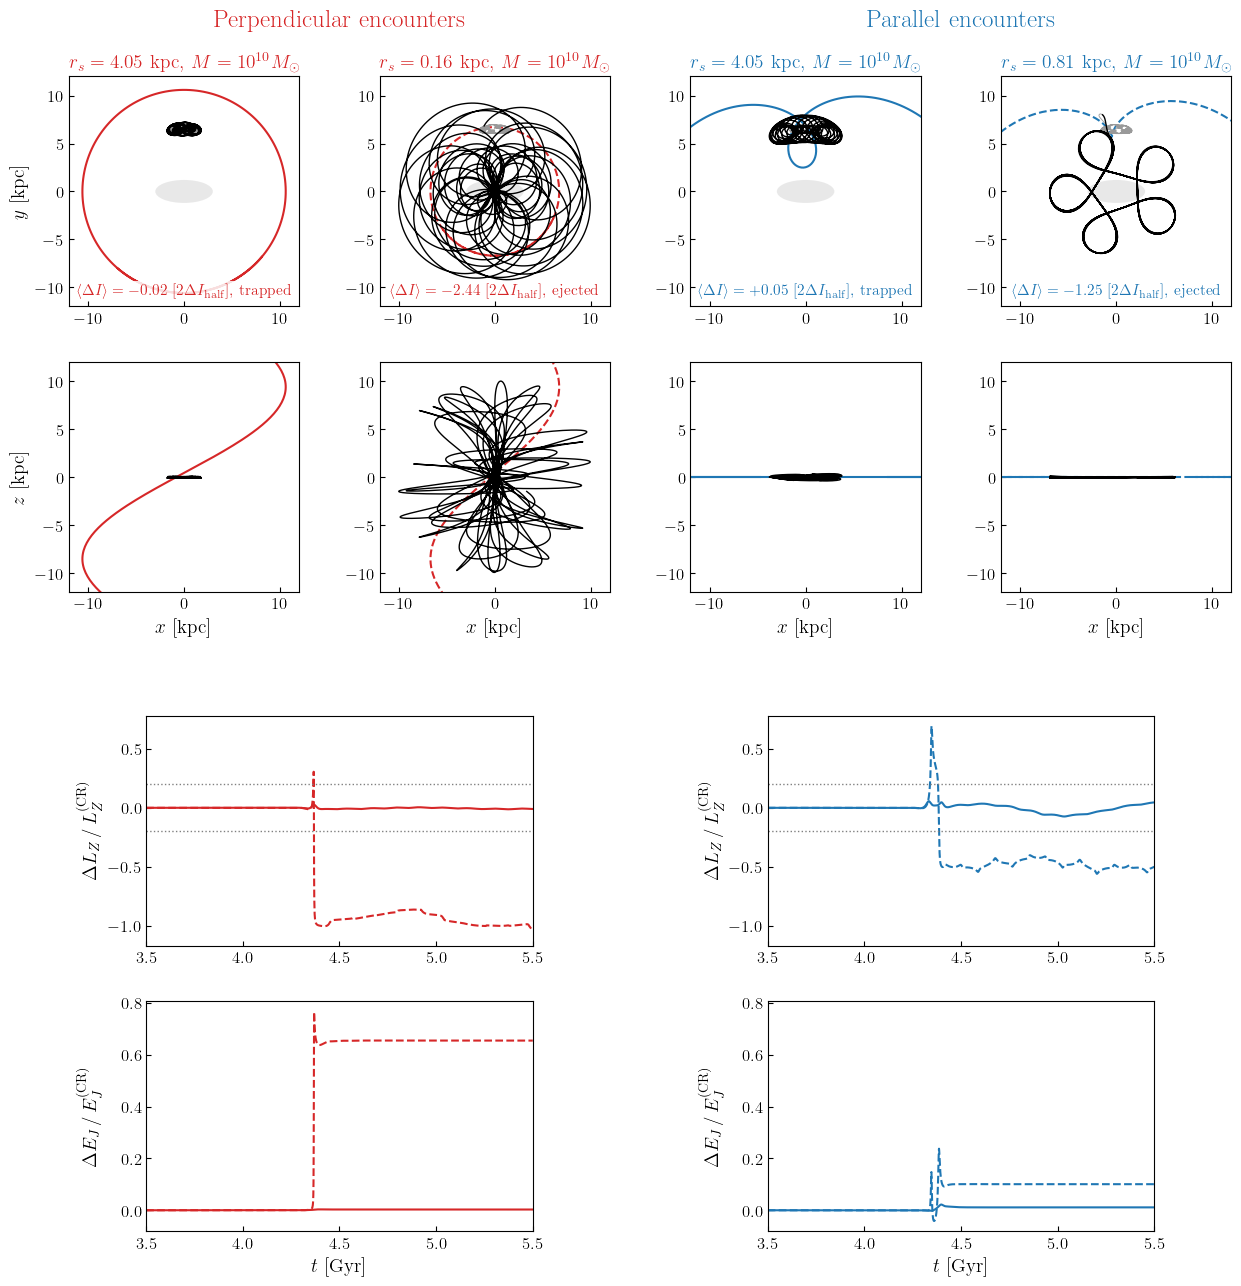

In [6]:
fig7 = {(g, k): flyby(M_FIG7, f, g, BDIR_FIG7[g]) for g in ('vertical', 'parallel') for k, f in enumerate(FS_FIG7[g])}
for (g, k), r in fig7.items():
    print(f"{g:8s} f = {FS_FIG7[g][k]:6.3f}  r_s = {r['rs']:5.2f} kpc  u = {r['u']:5.1f} km/s  "
          f"dI = {r['dI']:+.3f}  (pred {r['dI_pred']:+.3f}) [2 dI_half]  -> {fate(r)}")

fig = plt.figure(figsize=(15, 15))
gs  = GridSpec(5, 4, figure=fig, wspace=0.35, hspace=0.3, height_ratios=[1, 1, 0.05, 1, 1])
t_limits, rlim, r_show = (3.5, 5.5), 12, 25.       # r_show: draw the subhalo track while it is within r_show [kpc] of the centre
ie = fig7[('vertical', 0)]['ie']; sl_pre = slice(0, ie + 1); sl_post = slice(ie, None)

cols = dict(vertical='tab:red', parallel='tab:blue')
axes_orb = {}
for j, (g, k) in enumerate([('vertical', 0), ('vertical', 1), ('parallel', 0), ('parallel', 1)]):
    r, ls = fig7[(g, k)], ['-', '--'][k]
    win = np.linalg.norm(r['traj'], axis=1) < r_show
    for i, (a, bb, lab) in enumerate([(0, 1, '$y$ [kpc]'), (0, 2, '$z$ [kpc]')]):
        ax = fig.add_subplot(gs[i, j]); ax.set(xlim=(-rlim, rlim), ylim=(-rlim, rlim)); ax.set_rasterization_zorder(10)
        if i == 0: ax.add_patch(make_bar(**bar_kwargs))
        ax.plot(r['traj_cr'][win, a], r['traj_cr'][win, bb], color=cols[g], ls=ls)
        ax.plot(r['xp_cr'][sl_pre, a], r['xp_cr'][sl_pre, bb], color='0.6', lw=0.6)
        ax.plot(r['xp_cr'][sl_post, a], r['xp_cr'][sl_post, bb], color='k', lw=1.0)
        if j == 0: ax.set_ylabel(lab)
        if i == 1: ax.set_xlabel('$x$ [kpc]')
        if i == 0:
            ax.set_title(f"$r_s = {r['rs']:.2f}$ kpc, $M = 10^{{{int(np.log10(M_FIG7))}}} M_\\odot$", c=cols[g], fontsize=14)
            ax.text(0.5, 0.05, rf"${DI_SYM} = {r['dI']:+.2f}$ [$2\Delta I_{{\rm half}}$], {fate(r)}",
                    transform=ax.transAxes, ha='center', fontsize=11, color=cols[g], bbox=label_box)
        ax.tick_params(direction='in'); axes_orb[(i, j)] = ax

axL, axE = {}, {}
for j, g in enumerate(('vertical', 'parallel')):
    sub3 = gs[3, 2*j:2*j+2].subgridspec(1, 3, width_ratios=[0.2, 1, 0.2], wspace=0.0)
    sub4 = gs[4, 2*j:2*j+2].subgridspec(1, 3, width_ratios=[0.2, 1, 0.2], wspace=0.0)
    axL[g] = fig.add_subplot(sub3[0, 1], sharey=axL.get('vertical'))
    axE[g] = fig.add_subplot(sub4[0, 1], sharey=axE.get('vertical'))
    for k, ls in enumerate(['-', '--']):
        r = fig7[(g, k)]
        axL[g].plot(times, (r['LZ'] - LZ)/LZ_CR, color=cols[g], ls=ls)
        axE[g].plot(times, (r['EJ'] - EJ)/EJ, color=cols[g], ls=ls)
    for s in (+1, -1): axL[g].axhline(s*m_res*dI_half/LZ_CR, color='0.5', ls=':', lw=1)
    for ax in (axL[g], axE[g]):
        ax.set_xlim(t_limits); ax.set_rasterization_zorder(10); ax.tick_params(direction='in')
    axL[g].set_ylabel(r'$\Delta L_Z \, / \, L_Z^{(\rm CR)}$')
    axE[g].set_ylabel(r'$\Delta E_J \, / \, E_J^{(\rm CR)}$')
    axE[g].set_xlabel(r'$t$ [Gyr]')
    fig.align_ylabels([axL[g], axE[g]])

for j0, txt, c in [(0, "Perpendicular encounters", 'tab:red'), (2, "Parallel encounters", 'tab:blue')]:
    p0, p1 = axes_orb[(0, j0)].get_position(), axes_orb[(0, j0 + 1)].get_position()
    fig.text((p0.x0 + p1.x1)/2, p0.y1 + 0.03, txt, ha="center", va="bottom", fontsize=18, fontweight="bold", color=c)

if SAVE_FIGS: plt.savefig('../figures/subhalo_flyby_xz.pdf', dpi=400, bbox_inches='tight')
plt.show()

## Figure 8: example outcomes on vertical trajectories

Each panel is labelled with $|\langle\Delta I\rangle|$, the change in slow action averaged over one radial period (with `MEAS = 'orbit_avg'`), in units of $2\Delta I_{\rm half}$ and with the outcome (trapped or ejected). The concentrations are chosen per mass (`FS_FIG8`) so that each row has a similar $|\langle\Delta I\rangle|$. The top two rows are trapped. The bottom two are ejected with $|\langle\Delta I\rangle|>2$.

In the ejected rows, the predicted velocity kick at $b=r_s$ ($\simeq 0.9$–$1.4\times10^3\,{\rm km\,s^{-1}}$) is several times the encounter speed $u\simeq 310\,{\rm km\,s^{-1}}$, so the impulse approximation does not apply. $\langle\Delta I\rangle$ is negative there, while the analytic kick is positive.

M = 1e9, f =  1.000, r_s =  5.123 kpc:  dI = +0.004  (pred +0.010)  -> trapped
M = 1e10, f =  1.000, r_s = 16.200 kpc:  dI = +0.005  (pred +0.006)  -> trapped
M = 1e9, f =  0.100, r_s =  0.512 kpc:  dI = +0.148  (pred +0.188)  -> trapped
M = 1e10, f =  0.150, r_s =  2.430 kpc:  dI = +0.147  (pred +0.325)  -> trapped
M = 1e9, f =  0.003, r_s =  0.015 kpc:  dI = -2.381  (pred +6.377)  -> ejected
M = 1e10, f =  0.010, r_s =  0.162 kpc:  dI = -2.512  (pred +6.035)  -> ejected


M = 1e9, f =  0.002, r_s =  0.010 kpc:  dI = -2.994  (pred +9.566)  -> ejected
M = 1e10, f =  0.007, r_s =  0.113 kpc:  dI = -3.036  (pred +8.630)  -> ejected


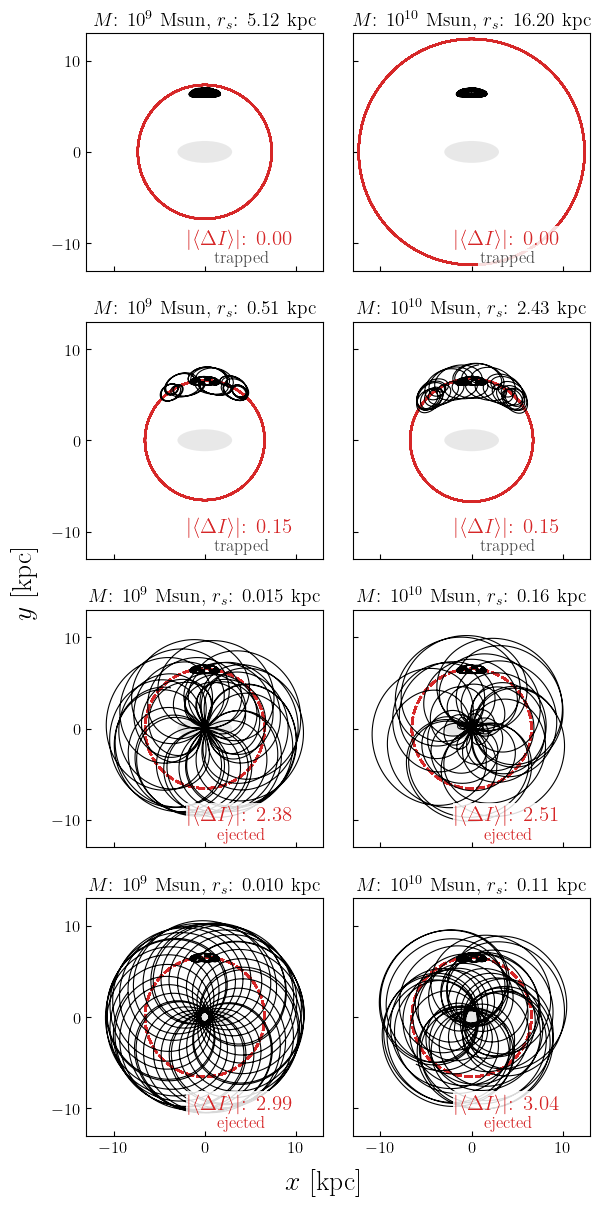

In [7]:
n_rows = len(FS_FIG8[M_FIG8[0]])
fig, axes = plt.subplots(n_rows, len(M_FIG8), figsize=(6, 3*n_rows))
fig8 = {}
for i in range(n_rows):
    for j, M in enumerate(M_FIG8):
        f = FS_FIG8[M][i]
        r = fig8[(M, f)] = flyby(M, f, 'vertical', 'azimuth')
        ax = axes[i, j]
        ax.set_rasterization_zorder(10); ax.add_patch(make_bar(**bar_kwargs))
        ax.plot(r['traj_cr'][:, 0], r['traj_cr'][:, 1], color='tab:red', linestyle='--')
        ax.plot(r['xp_cr'][:, 0], r['xp_cr'][:, 1], color='black', lw=0.8)
        ax.set_title(f'$M$: $10^{{{int(np.log10(M))}}}$ Msun, $r_s$: {r["rs"]:.{2 if r["rs"] >= 0.1 else 3}f} kpc', fontsize=14)
        ax.set(xlim=(-13, 13), ylim=(-13, 13), xticks=[-10, 0, 10], yticks=[-10, 0, 10])
        ax.label_outer(); ax.set_box_aspect(1); ax.tick_params(direction='in')
        ax.text(4, -9.5, rf'$|{DI_SYM}|$: {abs(r["dI"]):.2f}', fontsize=15, ha='center', va='center', color='tab:red', bbox=label_box)
        ax.text(4, -11.7, fate(r), fontsize=12, ha='center', va='center', color='tab:red' if r['ejected'] else '0.3', bbox=label_box)
        print(f"M = 1e{np.log10(M):.0f}, f = {f:6.3f}, r_s = {r['rs']:6.3f} kpc:  dI = {r['dI']:+.3f}  (pred {r['dI_pred']:+.3f})  -> {fate(r)}")

fig.text(0.50, 0.00, '$x$ [kpc]', ha='center', va='center', fontsize=20)
fig.text(0.00, 0.50, '$y$ [kpc]', ha='center', va='center', rotation='vertical', fontsize=20)
plt.tight_layout()
if SAVE_FIGS: plt.savefig('../figures/orbit_examples.pdf', dpi=400, bbox_inches='tight')
plt.show()